# PLS Regression — Implementação com validação temporal
**Grupo 1 | Bitcoin diário**

Implementa PLS com as features congeladas, reproduz a seleção temporal de `n_components` e ajusta o modelo final no treino. A predição direta no bloco de teste é exibida apenas como demonstração complementar; a métrica oficial de avaliação está no walk-forward do pipeline, consultado no notebook 03. Nenhum arquivo é criado.

Raiz do projeto: C:\Users\raqueltolomei-ieg\OneDrive - Instituto Germinare\Área de Trabalho\3 ano\Séries Temporais\PLSRegretion\pls-regration-comparation
Treino: 1996 dias | 2018-11-20 a 2024-05-07
Teste: 856 dias | 2024-05-08 a 2026-09-10
Features: 51 | alvo: target | random_state de protocolo: 42
PLSRegression e deterministico; o random_state nao controla o ajuste do estimador.

Melhor n_components por MAE_CV: 9
MAE_CV: USD 1,982.29 (± USD 1,412.91)
RMSE_CV: USD 2,564.30 | R2_CV: 0.8481


,n_components,mae_cv_mean,mae_cv_std,rmse_cv_mean,r2_cv_mean
0,9,1982.293706,1412.905319,2564.303205,0.848099
1,10,2001.335785,1571.544332,2572.210319,0.849942
2,11,2043.411593,1670.726854,2616.788330,0.844360
3,5,2073.281066,1480.051864,2735.249139,0.897861
4,6,2078.979613,1437.707148,2717.331768,0.884392
5,7,2097.919012,1334.227146,2708.309854,0.851248
6,8,2111.823433,1305.082215,2700.085249,0.832618
7,12,2153.627488,1861.922837,2749.289404,0.819246
8,13,2203.632931,1874.428319,2803.213469,0.784480
9,4,2293.424733,1590.398450,2956.268049,0.871947



Demonstracao holdout (ajuste unico no treino; nao substitui o walk-forward):
MAE: USD 2,738.67 | RMSE: USD 3,598.87 | R2: 0.9638

Features com maiores coeficientes absolutos no ajuste de treino:


,coeficiente
ratio_close_ma7,12523.955013
ratio_close_ma30,5465.783779
quarter_cos,1406.450456
oc_ratio_lag1,968.168300
month_cos,-469.995354
quarter,-346.016641
log_close_lag1,311.811854
doy_cos,-243.686022
log_close_lag7,198.610055
vol_pressure_lag1,160.351892


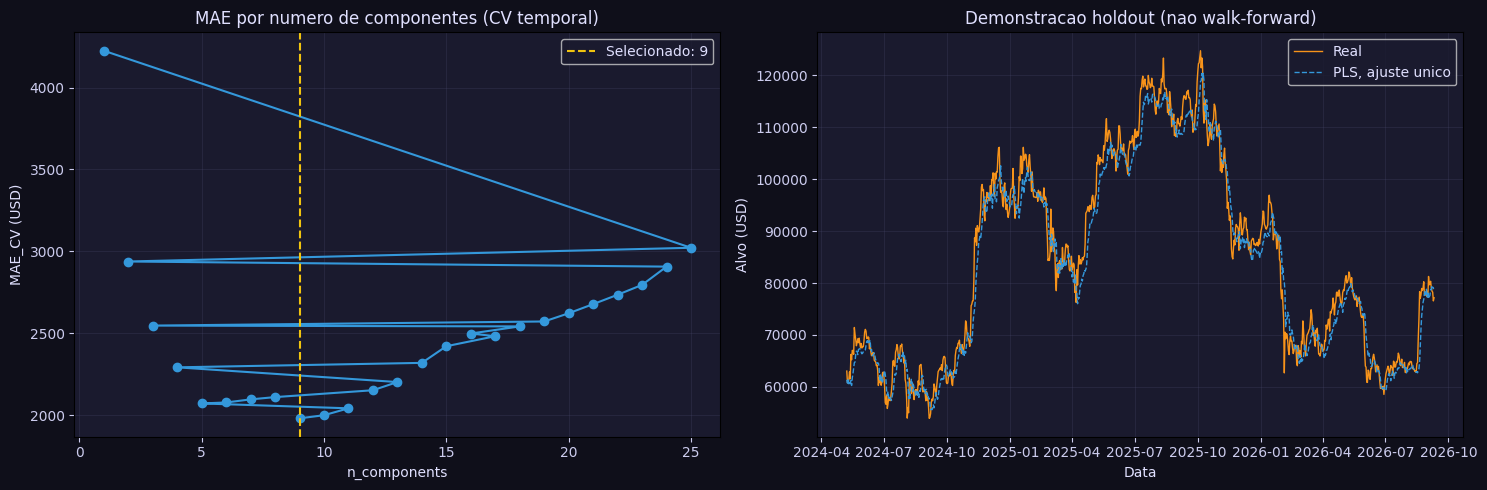


Nenhum grafico, CSV ou JSON foi salvo por este notebook.


In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TRAIN_RATIO = 0.70

# Resolve a raiz do projeto mesmo quando o kernel inicia em uma subpasta.
CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')
DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'

with (DATA_DIR / 'feature_metadata.json').open('r', encoding='utf-8') as file:
    metadata = json.load(file)
FEATURE_COLS = metadata['feature_cols']
TARGET_COL = metadata['target_col']
train = pd.read_csv(DATA_DIR / 'bitcoin_features_train.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
test = pd.read_csv(DATA_DIR / 'bitcoin_features_test.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)

if not np.isclose(metadata['train_ratio'], TRAIN_RATIO):
    raise ValueError('A divisao dos dados nao corresponde ao protocolo 70/30.')
if len(train) != metadata['n_train'] or len(test) != metadata['n_test']:
    raise ValueError('Os tamanhos dos dados nao correspondem aos metadados.')
if not (train['date'].max() < test['date'].min()):
    raise ValueError('Treino e teste nao estao em ordem cronologica.')

X_train = train[FEATURE_COLS].astype(float)
y_train = train[TARGET_COL].astype(float)
X_test = test[FEATURE_COLS].astype(float)
y_test = test[TARGET_COL].astype(float)
if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(y_train.to_numpy()).all():
    raise ValueError('O treino contem valores ausentes ou nao finitos.')
if not np.isfinite(X_test.to_numpy()).all() or not np.isfinite(y_test.to_numpy()).all():
    raise ValueError('O teste contem valores ausentes ou nao finitos.')

print(f'Raiz do projeto: {PROJECT_ROOT}')
print(f'Treino: {len(train)} dias | {train.date.min().date()} a {train.date.max().date()}')
print(f'Teste: {len(test)} dias | {test.date.min().date()} a {test.date.max().date()}')
print(f'Features: {len(FEATURE_COLS)} | alvo: {TARGET_COL} | random_state de protocolo: {RANDOM_STATE}')
print('PLSRegression e deterministico; o random_state nao controla o ajuste do estimador.')

# Seleciona n_components somente dentro do treino, preservando a ordem temporal.
MAX_COMPONENTS = min(25, len(FEATURE_COLS), len(X_train) - 1)
COMPONENTS = range(1, MAX_COMPONENTS + 1)
CV_SPLITS = 5
cv = TimeSeriesSplit(n_splits=CV_SPLITS)
cv_rows = []

for n_components in COMPONENTS:
    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    for train_idx, validation_idx in cv.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_validation = X_train.iloc[validation_idx]
        y_validation = y_train.iloc[validation_idx]

        model = PLSRegression(n_components=n_components, scale=True)
        model.fit(X_fold_train, y_fold_train)
        validation_predictions = model.predict(X_validation).ravel()
        fold_mae.append(mean_absolute_error(y_validation, validation_predictions))
        fold_rmse.append(np.sqrt(mean_squared_error(y_validation, validation_predictions)))
        fold_r2.append(r2_score(y_validation, validation_predictions))

    cv_rows.append({
        'n_components': n_components,
        'mae_cv_mean': float(np.mean(fold_mae)),
        'mae_cv_std': float(np.std(fold_mae)),
        'rmse_cv_mean': float(np.mean(fold_rmse)),
        'r2_cv_mean': float(np.mean(fold_r2))
    })

cv_results = pd.DataFrame(cv_rows).sort_values('mae_cv_mean').reset_index(drop=True)
best_row = cv_results.iloc[0]
optimal_n_components = int(best_row['n_components'])
print(f'\nMelhor n_components por MAE_CV: {optimal_n_components}')
print(f"MAE_CV: USD {best_row['mae_cv_mean']:,.2f} (± USD {best_row['mae_cv_std']:,.2f})")
print(f"RMSE_CV: USD {best_row['rmse_cv_mean']:,.2f} | R2_CV: {best_row['r2_cv_mean']:.4f}")
display(cv_results.head(10))

# Reajusta no conjunto completo de treino; scale=True evita escalar com informacao do teste.
pls_final = PLSRegression(n_components=optimal_n_components, scale=True)
pls_final.fit(X_train, y_train)
test_predictions = pls_final.predict(X_test).ravel()
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = float(np.sqrt(mean_squared_error(y_test, test_predictions)))
test_r2 = r2_score(y_test, test_predictions)
print('\nDemonstracao holdout (ajuste unico no treino; nao substitui o walk-forward):')
print(f'MAE: USD {test_mae:,.2f} | RMSE: USD {test_rmse:,.2f} | R2: {test_r2:.4f}')

coefficients = pd.Series(pls_final.coef_.ravel(), index=FEATURE_COLS, name='coeficiente')
print('\nFeatures com maiores coeficientes absolutos no ajuste de treino:')
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).head(15).index).to_frame())

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': '#e0e0ff', 'xtick.color': '#ccccee',
    'ytick.color': '#ccccee', 'text.color': '#e0e0ff', 'grid.color': '#444466'
})
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='#0f0f1a')
axes[0].plot(cv_results['n_components'], cv_results['mae_cv_mean'], marker='o', color='#3498db')
axes[0].axvline(optimal_n_components, color='#f1c40f', ls='--', label=f'Selecionado: {optimal_n_components}')
axes[0].set(title='MAE por numero de componentes (CV temporal)', xlabel='n_components', ylabel='MAE_CV (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(test['date'], y_test, color='#f7931a', lw=1, label='Real')
axes[1].plot(test['date'], test_predictions, color='#3498db', lw=1, ls='--', label='PLS, ajuste unico')
axes[1].set(title='Demonstracao holdout (nao walk-forward)', xlabel='Data', ylabel='Alvo (USD)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print('\nNenhum grafico, CSV ou JSON foi salvo por este notebook.')